In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import warnings
import os
import joblib
import optuna
import plotly.express as px

from datetime import datetime
import math

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', 55)
warnings.filterwarnings('ignore')
import plotly.io as pio
pio.renderers.default = "kaggle"

d:\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df=pd.read_csv('/NYC/nyc_docs/data/raw/Nyc_taxi_fare.csv')
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0
...,...,...,...,...,...,...,...,...,...,...,...
2083773,id3008929,1,2016-01-01 00:02:52,NaN,1,-74.003464,40.725105,-74.001251,40.733643,N,NaN
2083774,id3700764,1,2016-01-01 00:01:52,NaN,1,-74.006363,40.743782,-73.953407,40.782467,N,NaN
2083775,id2568735,1,2016-01-01 00:01:24,NaN,2,-73.972267,40.759865,-73.876602,40.748665,N,NaN
2083776,id1384355,1,2016-01-01 00:00:28,NaN,1,-73.976501,40.733562,-73.854263,40.891788,N,NaN


In [4]:
# Missing value
df.isnull().sum()

id                         0
vendor_id                  0
pickup_datetime            0
dropoff_datetime      625134
passenger_count            0
pickup_longitude           0
pickup_latitude            0
dropoff_longitude          0
dropoff_latitude           0
store_and_fwd_flag         0
trip_duration         625134
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2083778 entries, 0 to 2083777
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   id                  str    
 1   vendor_id           int64  
 2   pickup_datetime     str    
 3   dropoff_datetime    str    
 4   passenger_count     int64  
 5   pickup_longitude    float64
 6   pickup_latitude     float64
 7   dropoff_longitude   float64
 8   dropoff_latitude    float64
 9   store_and_fwd_flag  str    
 10  trip_duration       float64
dtypes: float64(5), int64(2), str(4)
memory usage: 174.9 MB


In [6]:
df.nunique()

id                    2083778
vendor_id                   2
pickup_datetime       1926217
dropoff_datetime      1380377
passenger_count            10
pickup_longitude        24960
pickup_latitude         48068
dropoff_longitude       36977
dropoff_latitude        67086
store_and_fwd_flag          2
trip_duration            7417
dtype: int64

In [7]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [8]:
df['hour'] = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek 
df['day_name'] = df['pickup_datetime'].dt.day_name()   
df['month'] = df['pickup_datetime'].dt.month
df['day'] = df['pickup_datetime'].dt.day
df['is_weekend'] = df['pickup_datetime'].dt.dayofweek

In [9]:
df

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,day_of_week,day_name,month,day,is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0,17,0,Monday,3,14,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0,0,6,Sunday,6,12,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124.0,11,1,Tuesday,1,19,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0,19,2,Wednesday,4,6,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0,13,5,Saturday,3,26,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2083773,id3008929,1,2016-01-01 00:02:52,NaN,1,-74.003464,40.725105,-74.001251,40.733643,N,NaN,0,4,Friday,1,1,4
2083774,id3700764,1,2016-01-01 00:01:52,NaN,1,-74.006363,40.743782,-73.953407,40.782467,N,NaN,0,4,Friday,1,1,4
2083775,id2568735,1,2016-01-01 00:01:24,NaN,2,-73.972267,40.759865,-73.876602,40.748665,N,NaN,0,4,Friday,1,1,4
2083776,id1384355,1,2016-01-01 00:00:28,NaN,1,-73.976501,40.733562,-73.854263,40.891788,N,NaN,0,4,Friday,1,1,4


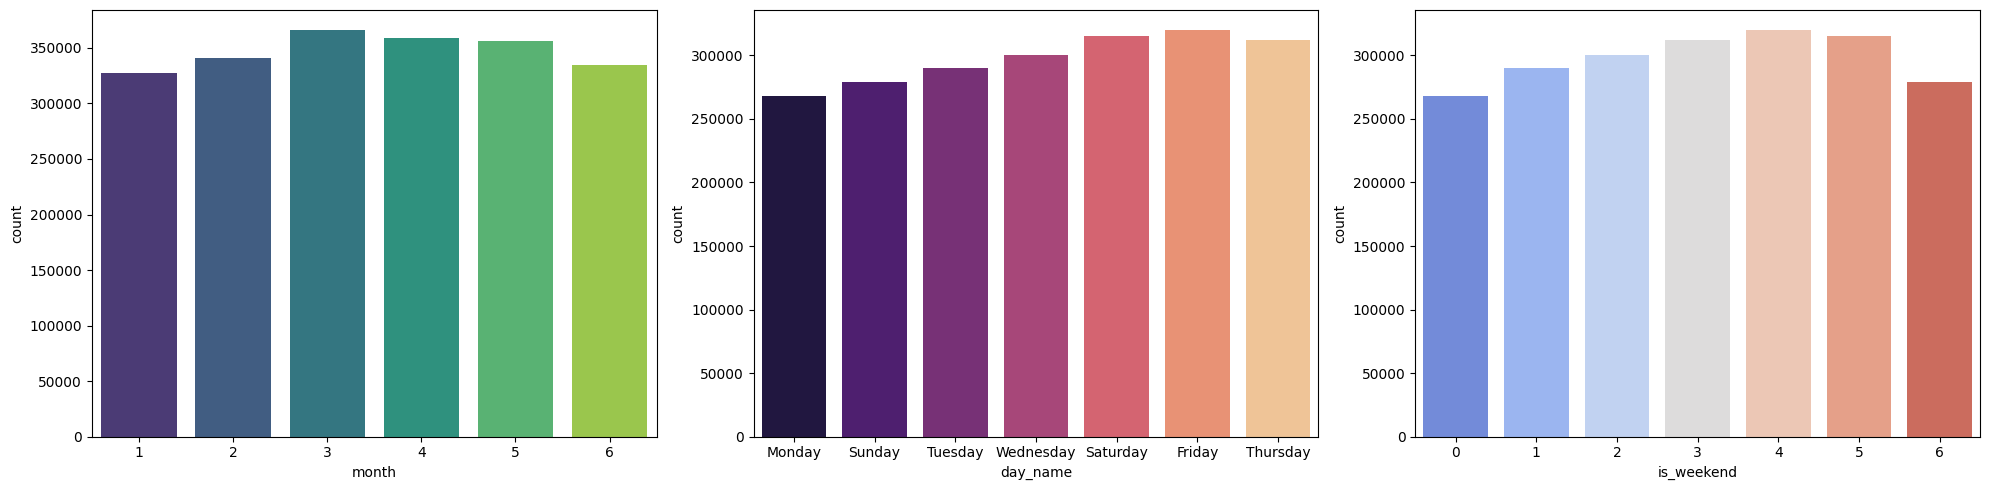

In [10]:
plt.figure(figsize=(20, 5))
for i, col in enumerate(['month', 'day_name', 'is_weekend'], 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df[col], palette="viridis" if i==1 else "magma" if i==2 else "coolwarm")
plt.tight_layout(); plt.show()

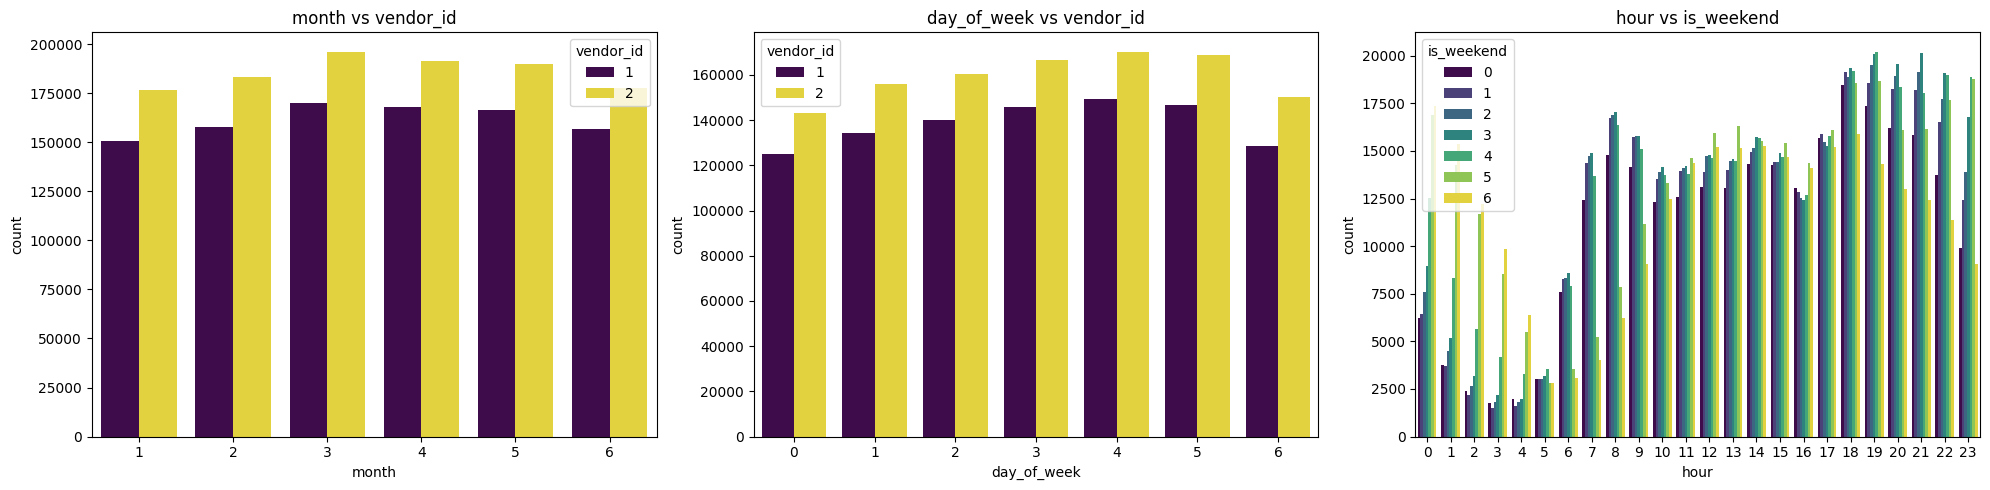

In [11]:
plt.figure(figsize=(20, 5))
for i, (col, h) in enumerate(zip(['month', 'day_of_week', 'hour'], ['vendor_id', 'vendor_id', 'is_weekend']), 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue=h, data=df, palette="viridis").set_title(f'{col} vs {h}')
plt.tight_layout(); plt.show()

he top row shows the univariate distribution of key features. We observe that taxi trips peaked around March and April. The "day_name" plot reveals that Fridays and Saturdays are the busiest days in New York City. The "is_weekend" chart highlights the class imbalance between weekdays and weekends, which is crucial for the model to understand regular traffic patterns.The bottom row presents a bivariate analysis using the "hue" parameter for deeper insights. The first two plots show that Vendor 2 consistently handles more trips than Vendor 1 across all months and days. The most critical insight comes from the "Hour vs. Is_weekend" plot: weekdays show clear peaks during morning and evening rush hours, while weekends exhibit a more gradual increase toward the afternoon. This confirms that time-based features are powerful predictors for trip duration.

In [12]:
df['is_rush_hour'] = ((df['day_of_week'] <= 4) & (df['hour'].between(16, 19))).astype(int) 
# Hafta içi (0-4) ve iş çıkış saati (16-19) ise 1, değilse 0
df['log_trip_duration'] = np.log1p(df['trip_duration'])

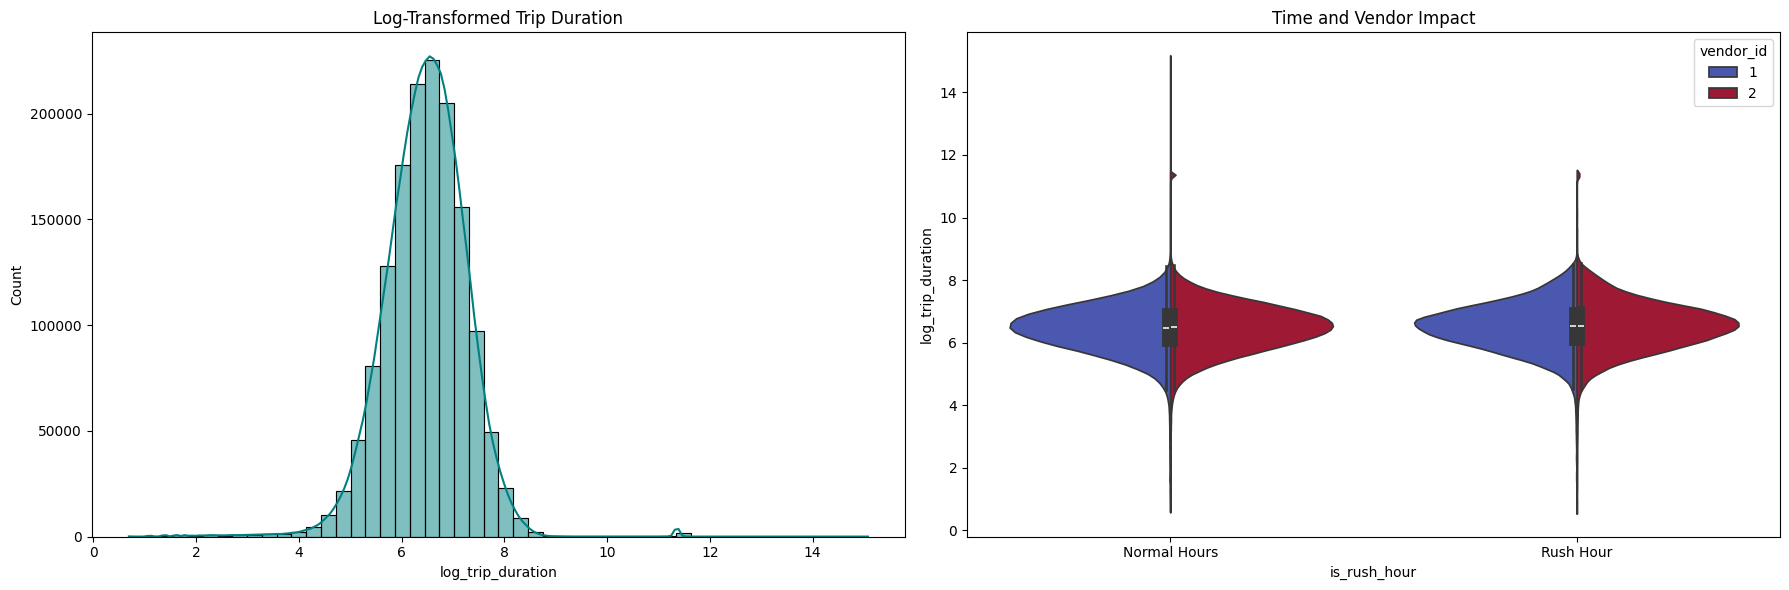

In [13]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['log_trip_duration'], bins=50, kde=True, color='teal')
plt.title("Log-Transformed Trip Duration")

plt.subplot(1, 2, 2)
sns.violinplot(x='is_rush_hour', y='log_trip_duration', hue='vendor_id', data=df[df['trip_duration'].notnull()], split=True, palette="coolwarm")
plt.title("Time and Vendor Impact")
plt.xticks([0, 1], ['Normal Hours', 'Rush Hour'])
plt.tight_layout(); plt.show()

The left histogram confirms that the log_trip_duration follows a clean Normal Distribution, which is essential for reducing error in regression models like XGBoost. By compressing the extreme values through log transformation, you've made the data more predictable for the machine.

The right violin plot serves as a validation of your Feature Engineering. It visually demonstrates that trip durations significantly increase during Rush Hour (notice the clear upward shift of the violins compared to Normal Hours). This shift is the definitive proof that traffic between 16:00-19:00 directly extends travel time. It also indicates that both vendors are equally affected by congestion, proving that the "time of day" is a much stronger predictor than the "company ID."

In [14]:
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 0 and x <= 5 else 0)        
  # Gece 00 ile sabah 05 arası

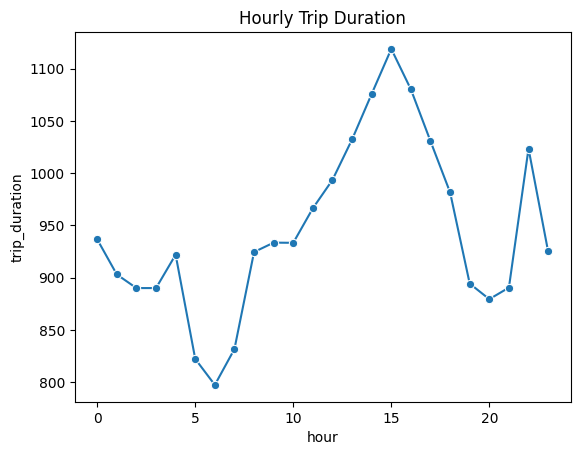

In [15]:
stats = df.groupby('hour').trip_duration.mean().reset_index()
sns.lineplot(data=stats, x='hour', y='trip_duration', marker='o')

# Başlık ve göster
plt.title("Hourly Trip Duration")
plt.show()

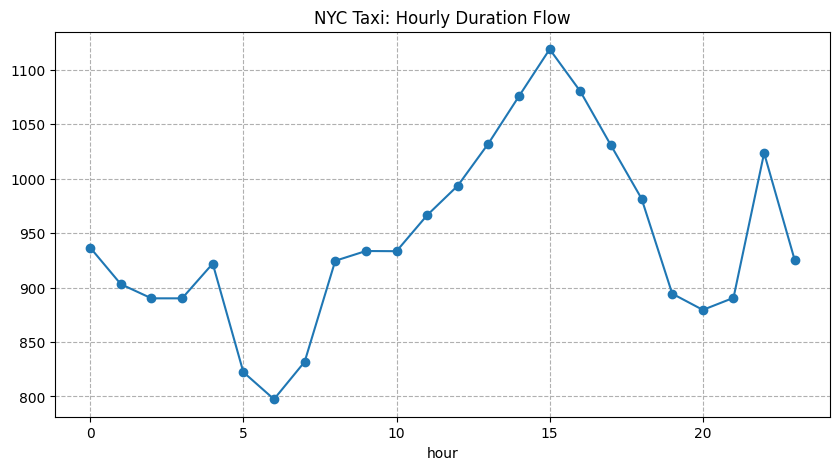

In [16]:
h_s = df.groupby('hour').trip_duration.mean()
h_s.plot(kind='line', marker='o', figsize=(10, 5), grid=True)
plt.grid(linestyle='--')
plt.title("NYC Taxi: Hourly Duration Flow")
plt.show()

The hourly analysis of NYC taxi data clearly reveals the city's traffic rhythm. Trip durations begin to decrease after midnight, reaching their lowest point at 06:00 AM, before climbing rapidly with the onset of the morning commute. The daily peak occurs around 03:00 PM, surpassing 1100 seconds due to the convergence of school runs and commercial deliveries; while a relative easing follows the end of the workday, a minor "nightlife pulse" is observed around 10:00 PM as the city stays active.

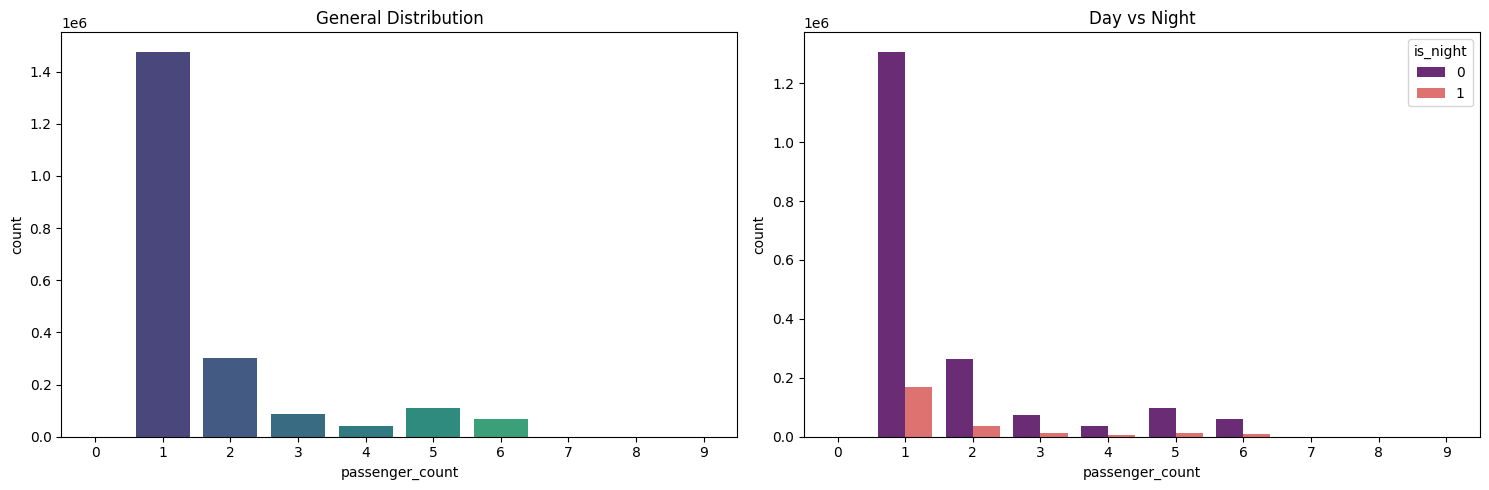

In [17]:
plt.figure(figsize=(15, 5))
plt.subplot(121); sns.countplot(x="passenger_count", data=df, palette="viridis")
plt.title("General Distribution")
plt.subplot(122); sns.countplot(x="passenger_count", hue="is_night", data=df, palette="magma")
plt.title("Day vs Night")
plt.tight_layout(); plt.show()

The left plot highlights the dominant trend in the dataset: the vast majority of taxi trips (nearly 1.5 million) are made by solo passengers. This confirms that taxis primarily serve individual commuters or business travelers. The scarcity of 5 or 6-passenger trips suggests that larger groups are less common or require specific vehicle types.

The right plot adds a temporal layer to the analysis. While the total volume of daytime trips (purple) is much higher, the nighttime trips (pink) reveal a shift in behavior. Solo trips drop significantly at night, but multi-passenger groups maintain a more visible presence relative to the total nighttime volume. This suggests that nighttime taxi usage is often driven by social outings or groups traveling together after dark, whereas daytime usage is strictly functional and individualistic.

In [18]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])            # Mesafe: Haversine (Kuş uçuşu KM)
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df['dist_km'] = haversine(df['pickup_longitude'], df['pickup_latitude'],df['dropoff_longitude'], df['dropoff_latitude'])
df['manhattan_dist'] = (df['pickup_latitude'] - df['dropoff_latitude']).abs() + \
                                                (df['pickup_longitude'] - df['dropoff_longitude']).abs()  
df['direction'] = np.degrees(np.arctan2(df['dropoff_longitude'] - df['pickup_longitude'], df['dropoff_latitude'] - df['pickup_latitude']))   

In [19]:
df['dist_hour_interaction'] = df['dist_km'] * df['hour']                                   # Mesafe ve saat çarpımı (Trafik yoğunluğunun mesafeye olan etkisini öğretir)
df['dist_night_interaction'] = df['dist_km'] * df['is_night']                              # Gece mi gündüz mü ve mesafe ilişkisi

In [20]:
print(df[['trip_duration', 'dist_km', 'passenger_count']].describe())

       trip_duration       dist_km  passenger_count
count   1.458644e+06  2.083778e+06     2.083778e+06
mean    9.594923e+02  3.438628e+00     1.663700e+00
std     5.237432e+03  4.289263e+00     1.313358e+00
min     1.000000e+00  0.000000e+00     0.000000e+00
25%     3.970000e+02  1.231865e+00     1.000000e+00
50%     6.620000e+02  2.093730e+00     1.000000e+00
75%     1.075000e+03  3.877528e+00     2.000000e+00
max     3.526282e+06  1.240909e+03     9.000000e+00


Looking at this table, we can conclude that the "noise" in the data is extremely high. Specifically, the std (standard deviation) for trip_duration is 5237, indicating that the data is inconsistently distributed with extreme anomalies. If we feed this to the model as is, the model will struggle with the 40-day-long trip error and fail to accurately predict a standard 15-minute ride.

In [21]:
pio.renderers.default = "colab"
fig = px.scatter_mapbox(df.sample(frac=0.01, random_state=42),lat="pickup_latitude", lon="pickup_longitude", zoom=10, mapbox_style="carto-positron", 
                        title="NYC Taxi Pickups")
fig.update_traces(marker=dict(size=3, opacity=0.3))
fig.show(renderer="iframe")

In [22]:
hour_counts = df['hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['Hour', 'Trip_Count']
fig = px.bar(hour_counts,x='Hour', y='Trip_Count',color='Trip_Count', title="NYC Taxi Hourly Density (1% Sample)",color_continuous_scale='Inferno',
             labels={'Hour', 'Trip_Count'})
fig.show(renderer="iframe")

The bar chart illustrates a clear surge in NYC taxi demand as the day progresses, with a significant escalation starting from 07:00 AM and reaching its peak density between 06:00 PM and 08:00 PM (18:00–20:00). While the earlier analysis showed that trip durations peak at 03:00 PM due to traffic congestion, this density plot reveals that the highest volume of trips occurs later in the evening, likely driven by the transition from work to social activities. The contrast between these two visualizations highlights an important insight: the city is most congested in the afternoon, but it is at its busiest in terms of trip frequency during the evening rush, proving that high demand does not always linearly correlate with the longest travel times.

In [23]:
df['borough'] = df.apply(lambda x: 'Manhattan' if 40.70<x.pickup_latitude<40.87 
                         and -74.02<x.pickup_longitude<-73.91 else ('Brooklyn' 
                                                                    if 40.50<x.pickup_latitude<40.74 and -74.05<x.pickup_longitude<-73.85 
                                                                    else ('Queens' if 40.55<x.pickup_latitude<40.80 and -73.95<x.pickup_longitude<-73.70 
                                                                          else ('Bronx' if 40.80<x.pickup_latitude<40.91 and -73.93<x.pickup_longitude<-73.75 
                                                                                else 'Other'))), axis=1)
print(df.groupby('borough')[['trip_duration', 'dist_km']].agg(['count', 'mean']))

          trip_duration               dist_km           
                  count         mean    count       mean
borough                                                 
Bronx               504   928.174603      700   4.428208
Brooklyn          18185   964.207039    25966   3.968967
Manhattan       1365647   890.686716  1951187   2.927051
Other               820   399.382927     1163   4.918266
Queens            73488  2243.422151   104762  12.812245


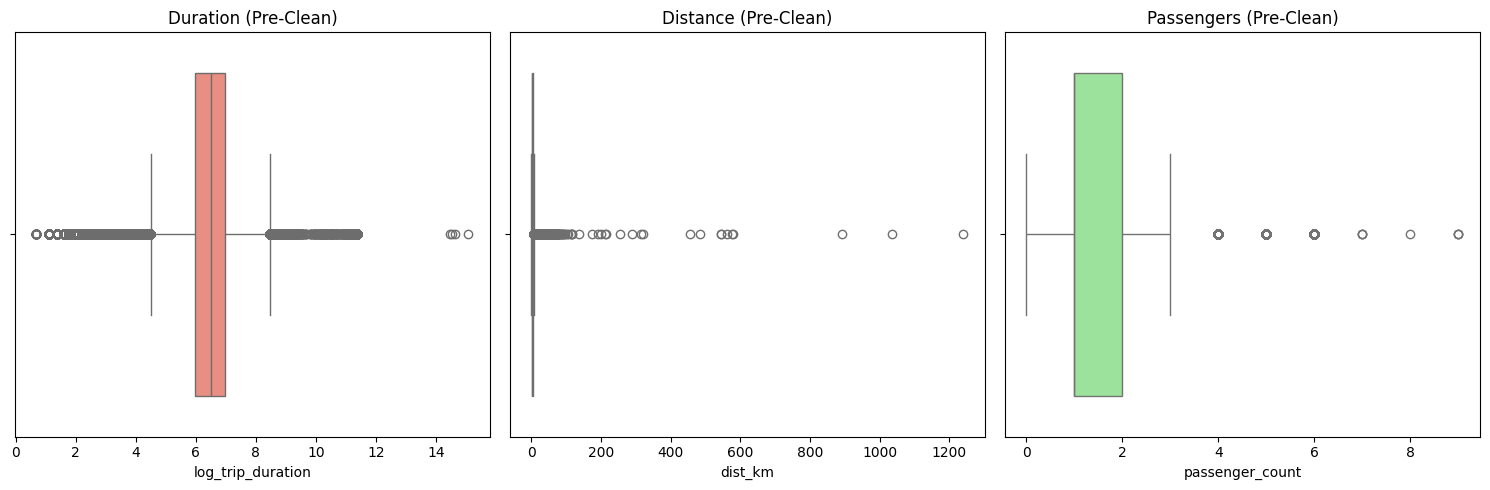

In [24]:
plt.figure(figsize=(15, 5))
plt.subplot(131); sns.boxplot(x=df['log_trip_duration'], color="salmon").set_title("Duration (Pre-Clean)")
plt.subplot(132); sns.boxplot(x=df['dist_km'], color="skyblue").set_title("Distance (Pre-Clean)")
plt.subplot(133); sns.boxplot(x=df['passenger_count'], color="lightgreen").set_title("Passengers (Pre-Clean)")
plt.tight_layout(); plt.show()

In [25]:
df = df[(df.dist_km > 0.1) & (df.dist_km <= 70)]                                         # 70 km sonrası kararlı değil, # Çok kısa ve imkansız uzunları at
df = df[(df.trip_duration > 30) & (df.trip_duration < 14400)]                            # Zaman sınırı aynı
df = df[(df.passenger_count > 0) & (df.passenger_count <= 3)] 

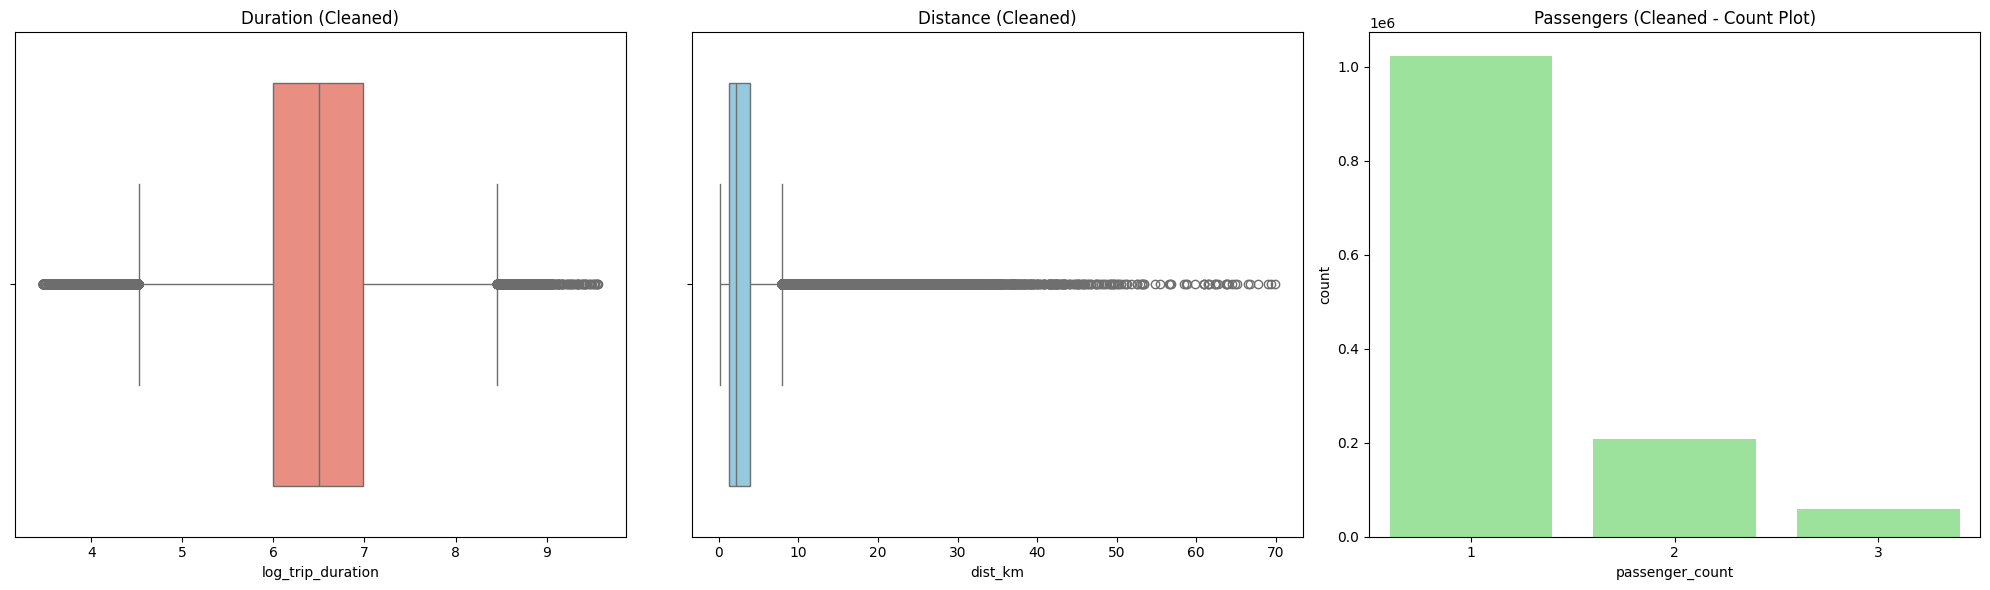

In [26]:
plt.figure(figsize=(20, 6))
plt.subplot(131); sns.boxplot(x=df['log_trip_duration'], color="salmon").set_title("Duration (Cleaned)")
plt.subplot(132); sns.boxplot(x=df['dist_km'], color="skyblue").set_title("Distance (Cleaned)")
plt.subplot(133); sns.countplot(x=df['passenger_count'], color="lightgreen").set_title("Passengers (Cleaned - Count Plot)")
plt.tight_layout(); plt.show()

The analysis of the cleaned dataset reveals that trip durations have approached a normal distribution through logarithmic transformation, effectively balancing out outliers. The distance plot confirms that while the majority of trips are concentrated over short distances (0-10 km), long-distance travels are still represented within the data. In the passenger count distribution, the absolute dominance of single-passenger trips—with over 1 million instances—is statistically evident, proving that New York taxi usage is primarily centered around individual transportation.

In [27]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'hour', 'day_of_week', 'day_name', 'month', 'day',
       'is_weekend', 'is_rush_hour', 'log_trip_duration', 'is_night',
       'dist_km', 'manhattan_dist', 'direction', 'dist_hour_interaction',
       'dist_night_interaction', 'borough'],
      dtype='str')

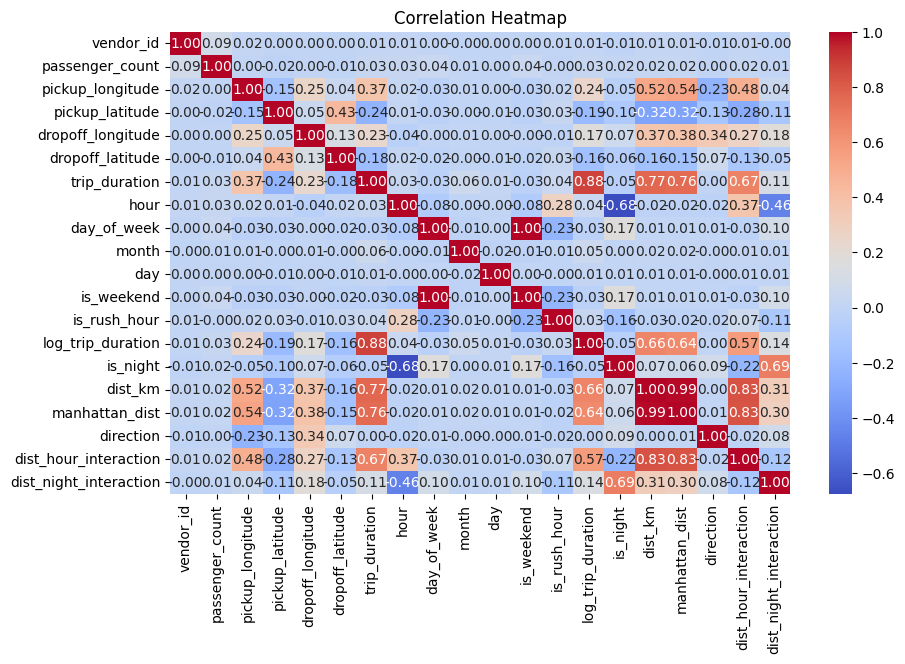

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show() 

The correlation heatmap clearly identifies the most decisive features for the model. In particular, the strong positive relationship of 0.77 between trip distance (dist_km) and the target variable (trip_duration) indicates that the machine learning model will possess high predictive power. On the other hand, the 0.99 correlation between dist_km and manhattan_dist proves that these two variables carry nearly identical information, providing crucial data for the feature selection and model simplification stage.

In [29]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 
            'hour', 'day_of_week', 'dist_km', 'manhattan_dist', 'is_rush_hour']
x = df[features]
y = df['log_trip_duration']

In [30]:
print(type(y))

<class 'pandas.Series'>


In [31]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=43)